In [2]:
import pandas as pd
import numpy as np
import os
import cv2
import time
import warnings
import tensorflow as tf
import geopandas as gpd
import seaborn as sns
import matplotlib.pyplot as plt
from shapely.geometry import Point
import random

from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.models import Model
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.optimizers import Adam

from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, r2_score

from sklearn.linear_model import Ridge, ElasticNet
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor, GradientBoostingRegressor
import xgboost as xgb
import lightgbm as lgb

warnings.filterwarnings('ignore')

In [3]:
# GPU SETUP & RESOURCE MANAGEMENT

gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print(f"✅ Found GPU: {len(gpus)} - Memory growth enabled")
    except RuntimeError as e: print(e)

In [4]:
# ตั้งค่า Path
IMAGE_DIR = r'C:\Users\Asus\Desktop\project\final\model\input_data\satellite_image'
CSV_PATH = r'C:\Users\Asus\Desktop\project\final\model\input_data\tabular\df_final_WithDis.csv'
SHP_ROOT_DIR = r'C:\Users\Asus\Desktop\project\final\model\input_data\shapfile\ALL_SHP'

# รายการไฟล์ Shapefile ทั้งหมด 14 รายการ
POI_PATHS = {
    'Airport':      os.path.join(SHP_ROOT_DIR, 'Airport.shp'),
    'clinic':       os.path.join(SHP_ROOT_DIR, 'clinic.shp'),
    'convenience':  os.path.join(SHP_ROOT_DIR, 'convenience_store.shp'),
    'school':       os.path.join(SHP_ROOT_DIR, 'school.shp'),
    'gov_service':  os.path.join(SHP_ROOT_DIR, 'gov_service.shp'),
    'Hospital':     os.path.join(SHP_ROOT_DIR, 'Hospital.shp'),
    'mall':         os.path.join(SHP_ROOT_DIR, 'mall.shp'),
    'night_club':   os.path.join(SHP_ROOT_DIR, 'night_club.shp'),
    'public_park':  os.path.join(SHP_ROOT_DIR, 'public_park.shp'),
    'restaurant':   os.path.join(SHP_ROOT_DIR, 'restaurant.shp'),
    'supermarket':  os.path.join(SHP_ROOT_DIR, 'supermarket.shp'),
    'university':   os.path.join(SHP_ROOT_DIR, 'university.shp'),
    'railway':      os.path.join(SHP_ROOT_DIR, 'railway.shp'),
    'E_railway':    os.path.join(SHP_ROOT_DIR, 'E_railway.shp')
}

df = pd.read_csv(CSV_PATH)
print(f"ขนาดข้อมูล: {df.shape}")
df.head()

ขนาดข้อมูล: (14722, 70)


,id,name,district,lat,long,sale_price,bedrooms,bathrooms,internal_area,floors,...,gov_service_1000m,Hospital_1000m,mall_1000m,night_club_1000m,public_park_1000m,restaurant_1000m,supermarket_1000m,Airport_1000m,E_railway_1000m,railway_1000m
0,1041,Suan Thon Park Condo,Thung Khru,13.652504,100.487825,1650000,2,1,56.0,12,...,0,0,0,1,0,6,1,0,0,0
1,795,Origins Rama 2,Chom Thong,13.654157,100.423897,1550000,1,1,28.0,8,...,0,0,0,1,0,1,0,0,0,0
2,795,Origins Rama 2,Chom Thong,13.654157,100.423897,1187000,1,1,30.0,8,...,0,0,0,1,0,1,0,0,0,0
3,795,Origins Rama 2,Chom Thong,13.654157,100.423897,2600000,2,2,60.0,8,...,0,0,0,1,0,1,0,0,0,0
4,795,Origins Rama 2,Chom Thong,13.654157,100.423897,1187000,1,1,30.0,8,...,0,0,0,1,0,1,0,0,0,0


In [6]:
# SPATIAL DATA PROCESSING 

print("Generating POI Density Labels")
df_condo = pd.read_csv(CSV_PATH)
geometry = [Point(xy) for xy in zip(df_condo['long'], df_condo['lat'])]
gdf_condo = gpd.GeoDataFrame(df_condo, geometry=geometry)
gdf_condo.crs = "EPSG:4326"
gdf_condo = gdf_condo.to_crs("EPSG:32647") 

RADIUS_METER = 1000 # ตั้งค่าระยะ buffer
encodings_to_try = ['cp874', 'tis-620', 'utf-8', 'latin-1']

for category, shp_path in POI_PATHS.items():
    print(f"   - Processing: {category}...")
    if os.path.exists(shp_path):
        success = False
        for enc in encodings_to_try:
            try:
                gdf_poi = gpd.read_file(shp_path, encoding=enc).to_crs("EPSG:32647")
                buffer = gdf_condo.geometry.buffer(RADIUS_METER)
                gdf_condo[f'density_{category}'] = [gdf_poi.geometry.within(geom).sum() for geom in buffer]
                print(f"     ✅ Success with {enc}: Found {len(gdf_poi)} points")
                success = True; break
            except Exception: continue
        if not success: gdf_condo[f'density_{category}'] = 0
    else: gdf_condo[f'density_{category}'] = 0

poi_cols = [f'density_{c}' for c in POI_PATHS.keys()]
Y_poi_scaled = StandardScaler().fit_transform(gdf_condo[poi_cols].values)

Generating POI Density Labels
   - Processing: Airport...
   - Processing: clinic...
     ✅ Success with cp874: Found 115 points
   - Processing: convenience...
     ✅ Success with cp874: Found 1439 points
   - Processing: school...
     ✅ Success with cp874: Found 1140 points
   - Processing: gov_service...
     ✅ Success with cp874: Found 50 points
   - Processing: Hospital...
     ✅ Success with cp874: Found 129 points
   - Processing: mall...
     ✅ Success with cp874: Found 81 points
   - Processing: night_club...
     ✅ Success with cp874: Found 445 points
   - Processing: public_park...
     ✅ Success with cp874: Found 47 points
   - Processing: restaurant...
     ✅ Success with cp874: Found 2695 points
   - Processing: supermarket...
     ✅ Success with cp874: Found 170 points
   - Processing: university...
     ✅ Success with cp874: Found 62 points
   - Processing: railway...
   - Processing: E_railway...


In [7]:
# IMAGE FINE-TUNING

print("Fine-Tuning EfficientNet (Urban Knowledge Transfer)...")

def load_images_robust(ids, img_dir):
    imgs, idxs = [], []
    for i, img_id in enumerate(ids):
        path = os.path.join(img_dir, f"{img_id}.tif")
        if os.path.exists(path):
            img = cv2.imread(path)
            if img is not None:
                img = cv2.resize(cv2.cvtColor(img, cv2.COLOR_BGR2RGB), (224, 224))
                imgs.append(img.astype('float32') / 255.0)
                idxs.append(i)
    if len(imgs) == 0: raise ValueError("❌ No images loaded.")
    return np.stack(imgs, axis=0), idxs

X_imgs, valid_idx = load_images_robust(df_condo['id'].values, IMAGE_DIR)
Y_train_poi = Y_poi_scaled[valid_idx].astype('float32')
df_final_base = df_condo.iloc[valid_idx].reset_index(drop=True)


Fine-Tuning EfficientNet (Urban Knowledge Transfer)...


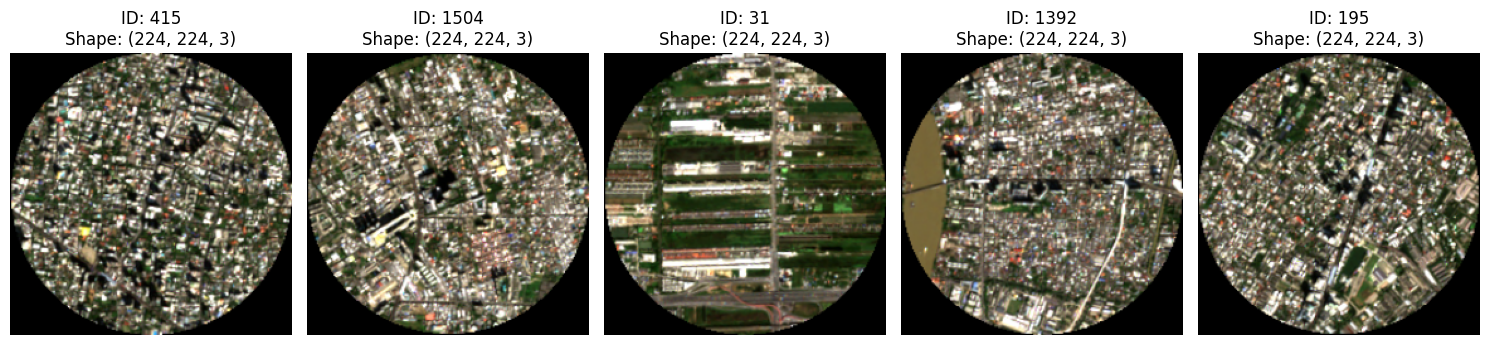

In [8]:
# แสดงตัวอย่างภาพหลังทำ Normalization
def visualize_processed_images(ids, img_dir, n_samples=5):
    
    sample_ids = random.sample(list(ids), min(n_samples, len(ids)))
    
    plt.figure(figsize=(15, 5))
    
    for i, img_id in enumerate(sample_ids):
        path = os.path.join(img_dir, f"{img_id}.tif")
        
        if os.path.exists(path):
            img = cv2.imread(path)
            if img is not None:
                # 1. แปลงสี BGR เป็น RGB (ตามที่ใช้ใน code จริง)
                img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
                
                # 2. Resize เป็น 224x224
                img_resized = cv2.resize(img_rgb, (224, 224))
                
                # 3. Normalization (หาร 255.0)
                img_normalized = img_resized.astype('float32') / 255.0
                
                # แสดงผล
                plt.subplot(1, n_samples, i + 1)
                plt.imshow(img_normalized)
                plt.title(f"ID: {img_id}\nShape: {img_normalized.shape}")
                plt.axis('off')
        else:
            print(f"ไม่พบไฟล์: {img_id}.tif")
            
    plt.tight_layout()
    plt.show()

visualize_processed_images(df_condo['id'].values, IMAGE_DIR)

In [9]:
# Build Model
base = EfficientNetB0(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
x = GlobalAveragePooling2D()(base.output)
x = Dense(512, activation='relu')(x)
poi_out = Dense(len(POI_PATHS), activation='linear')(x)
poi_model = Model(inputs=base.input, outputs=poi_out)

# Compile with Huber Loss & Advanced Metrics
poi_model.compile(
    optimizer=Adam(1e-4), 
    loss=tf.keras.losses.Huber(delta=1.0), 
    metrics=['mae', tf.keras.metrics.RootMeanSquaredError(name='rmse'), 'cosine_similarity']
)

print(f"Training Image Extractor on {X_imgs.shape[0]} images...")
early_stop = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)
poi_model.fit(X_imgs, Y_train_poi, batch_size=8, epochs=10, validation_split=0.2, callbacks=[early_stop], verbose=1)

Training Image Extractor on 14722 images...
Epoch 1/10
1473/1473 ━━━━━━━━━━━━━━━━━━━━ 977s 635ms/step - cosine_similarity: 0.8701 - loss: 0.0624 - mae: 0.2311 - rmse: 0.3800 - val_cosine_similarity: -0.2295 - val_loss: 0.2802 - val_mae: 0.6365 - val_rmse: 0.8101
Epoch 2/10
1473/1473 ━━━━━━━━━━━━━━━━━━━━ 958s 651ms/step - cosine_similarity: 0.9680 - loss: 0.0174 - mae: 0.1270 - rmse: 0.1905 - val_cosine_similarity: 0.6551 - val_loss: 0.1192 - val_mae: 0.3414 - val_rmse: 0.5888
Epoch 3/10
1473/1473 ━━━━━━━━━━━━━━━━━━━━ 896s 608ms/step - cosine_similarity: 0.9816 - loss: 0.0106 - mae: 0.0994 - rmse: 0.1474 - val_cosine_similarity: 0.4202 - val_loss: 0.1519 - val_mae: 0.4177 - val_rmse: 0.6245
Epoch 4/10
1473/1473 ━━━━━━━━━━━━━━━━━━━━ 906s 615ms/step - cosine_similarity: 0.9871 - loss: 0.0077 - mae: 0.0844 - rmse: 0.1253 - val_cosine_similarity: 0.0145 - val_loss: 0.2328 - val_mae: 0.5412 - val_rmse: 0.7393
Epoch 5/10
1473/1473 ━━━━━━━━━━━━━━━━━━━━ 959s 651ms/step - cosine_similarity: 0.98

In [10]:
# FEATURE EXTRACTION & PCA

print("Extracting Domain-Specific Features...")
extractor = Model(inputs=poi_model.input, outputs=poi_model.layers[-2].output)
image_features = extractor.predict(X_imgs, batch_size=8)

pca = PCA(n_components=50, random_state=42)
pca_feats = pca.fit_transform(image_features)
print(f"📊 PCA Variance Retained: {np.sum(pca.explained_variance_ratio_)*100:.2f}%")

df_img = pd.DataFrame(pca_feats, columns=[f'smart_img_{i}' for i in range(50)])
df_final = pd.concat([df_final_base, df_img], axis=1)

Extracting Domain-Specific Features...
1841/1841 ━━━━━━━━━━━━━━━━━━━━ 210s 112ms/step
📊 PCA Variance Retained: 83.14%


In [15]:
# เตรียมข้อมูลตาราง
print("เตรียมข้อมูลตาราง")

# Drop ข้อมูลที่ไม่ใช้งานและราคาซื้อขาย
drop_cols = ['sale_price', 'name', 'id','lat', 'long', 'geometry'] + poi_cols 

X = df_final.drop(columns=[c for c in drop_cols if c in df_final.columns])
y = np.log1p(df_final['sale_price'])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

preprocessor = ColumnTransformer([
    ('num', StandardScaler(), [c for c in X.columns if c != 'district']),
    ('cat', OneHotEncoder(handle_unknown='ignore'), ['district'])
])

เตรียมข้อมูลตาราง


In [16]:
# ตั้งค่า Params สำหรับ Grid search

model_params = {
    'Ridge': {
        'model': Ridge(),
        'params': {'regressor__alpha': [0.01, 1.0, 100.0]}
    },
    'KNN': {
        'model': KNeighborsRegressor(),
        'params': {'regressor__n_neighbors': [5, 10, 20], 'regressor__weights': ['uniform', 'distance']}
    },
    'RandomForest': {
        'model': RandomForestRegressor(random_state=42),
        'params': {'regressor__n_estimators': [100, 300], 'regressor__max_depth': [10, 20, None]}
    },
    'GradientBoosting': {
        'model': GradientBoostingRegressor(random_state=42),
        'params': {'regressor__n_estimators': [300, 500], 'regressor__learning_rate': [0.01, 0.05], 'regressor__max_depth': [3, 5]}
    },
    'XGBoost': {
        'model': xgb.XGBRegressor(objective='reg:squarederror', random_state=42, n_jobs=-1),
        'params': {
            'regressor__n_estimators': [500, 1000],
            'regressor__learning_rate': [0.01, 0.05],
            'regressor__max_depth': [5, 7]
        }
    },
    'LightGBM': {
        'model': lgb.LGBMRegressor(random_state=42, verbose=-1),
        'params': {
            'regressor__n_estimators': [500, 1000],
            'regressor__learning_rate': [0.01, 0.05],
            'regressor__num_leaves': [31, 50]
        }
    }
}


Run Grid Search...
   - Training Ridge...
     ✅ Done! MAE: 1,368,611 | R2: 0.8647
   - Training KNN...
     ✅ Done! MAE: 733,311 | R2: 0.9347
   - Training RandomForest...
     ✅ Done! MAE: 659,970 | R2: 0.9547
   - Training GradientBoosting...
     ✅ Done! MAE: 680,960 | R2: 0.9573
   - Training XGBoost...
     ✅ Done! MAE: 618,536 | R2: 0.9586
   - Training LightGBM...
     ✅ Done! MAE: 609,143 | R2: 0.9612

==========================================================================================FINAL LEADERBOARD (Multimodal Fine-Tuning)
           Model   MAE (Baht)  R2 Score  MAPE (%)
        LightGBM 6.091429e+05  0.961235 10.376778
         XGBoost 6.185358e+05  0.958648 10.565999
    RandomForest 6.599699e+05  0.954691 11.253293
GradientBoosting 6.809600e+05  0.957321 11.390228
             KNN 7.333108e+05  0.934667 12.328985
           Ridge 1.368611e+06  0.864716 21.022974


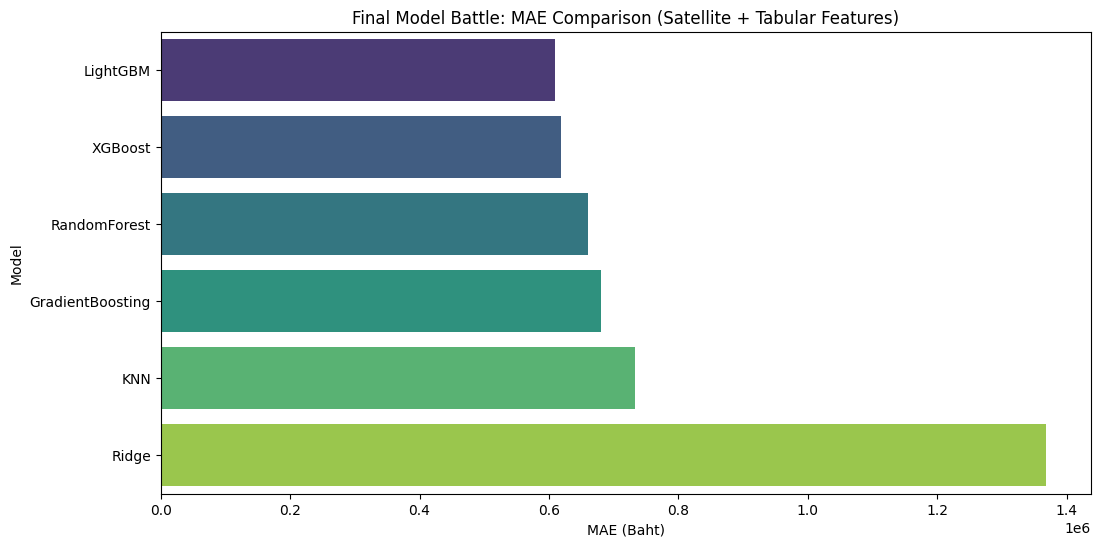

   - Best Model: LightGBM
   - Best MAE: 609,143 Baht
   - R2 Score: 0.9612
   - Best Config: {'regressor__learning_rate': 0.05, 'regressor__n_estimators': 1000, 'regressor__num_leaves': 50}


In [17]:
# Run Grid search
print("Run Grid Search...")

final_results = []
for name, mp in model_params.items():
    start_time = time.time()
    pipe = Pipeline([('preprocessor', preprocessor), ('regressor', mp['model'])])
    
    # Grid Search เน้นลด MAE
    grid = GridSearchCV(pipe, mp['params'], cv=3, scoring='neg_mean_absolute_error', n_jobs=-1)
    
    print(f"   - Training {name}...")
    try:
        grid.fit(X_train, y_train)
        
        # ประเมินผลและแปลง Log กลับเป็นค่าจริง
        best_model = grid.best_estimator_
        y_pred_log = best_model.predict(X_test)
        y_pred = np.expm1(y_pred_log)
        y_true = np.expm1(y_test)
        
        mae = mean_absolute_error(y_true, y_pred)
        r2 = r2_score(y_test, y_pred_log) # วัด R2 ใน Log Scale ตามมาตรฐานสถิติ
        mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
        
        final_results.append({
            'Model': name, 
            'MAE (Baht)': mae, 
            'R2 Score': r2, 
            'MAPE (%)': mape,
            'Params': grid.best_params_, 
            'Time (s)': time.time()-start_time
        })
        print(f"     ✅ Done! MAE: {mae:,.0f} | R2: {r2:.4f}")
    except Exception as e:
        print(f"     ❌ Error with {name}: {e}")

# Leaderboard Output
leaderboard = pd.DataFrame(final_results).sort_values('MAE (Baht)')
print("\n" + "="*90 + "FINAL LEADERBOARD (Multimodal Fine-Tuning)\n" + "="*90)
print(leaderboard[['Model', 'MAE (Baht)', 'R2 Score', 'MAPE (%)']].to_string(index=False))

# Visualization
plt.figure(figsize=(12, 6))
sns.barplot(x='MAE (Baht)', y='Model', data=leaderboard, palette='viridis')
plt.title('Final Model Battle: MAE Comparison (Satellite + Tabular Features)')
plt.show()

if not leaderboard.empty:
    winner = leaderboard.iloc[0]
    print(f"   - Best Model: {winner['Model']}")
    print(f"   - Best MAE: {winner['MAE (Baht)']:,.0f} Baht")
    print(f"   - R2 Score: {winner['R2 Score']:.4f}")
    print(f"   - Best Config: {winner['Params']}")

🎲 Randomly Selected Image Index: 14700
🔍 Analyzing Image ID: 891


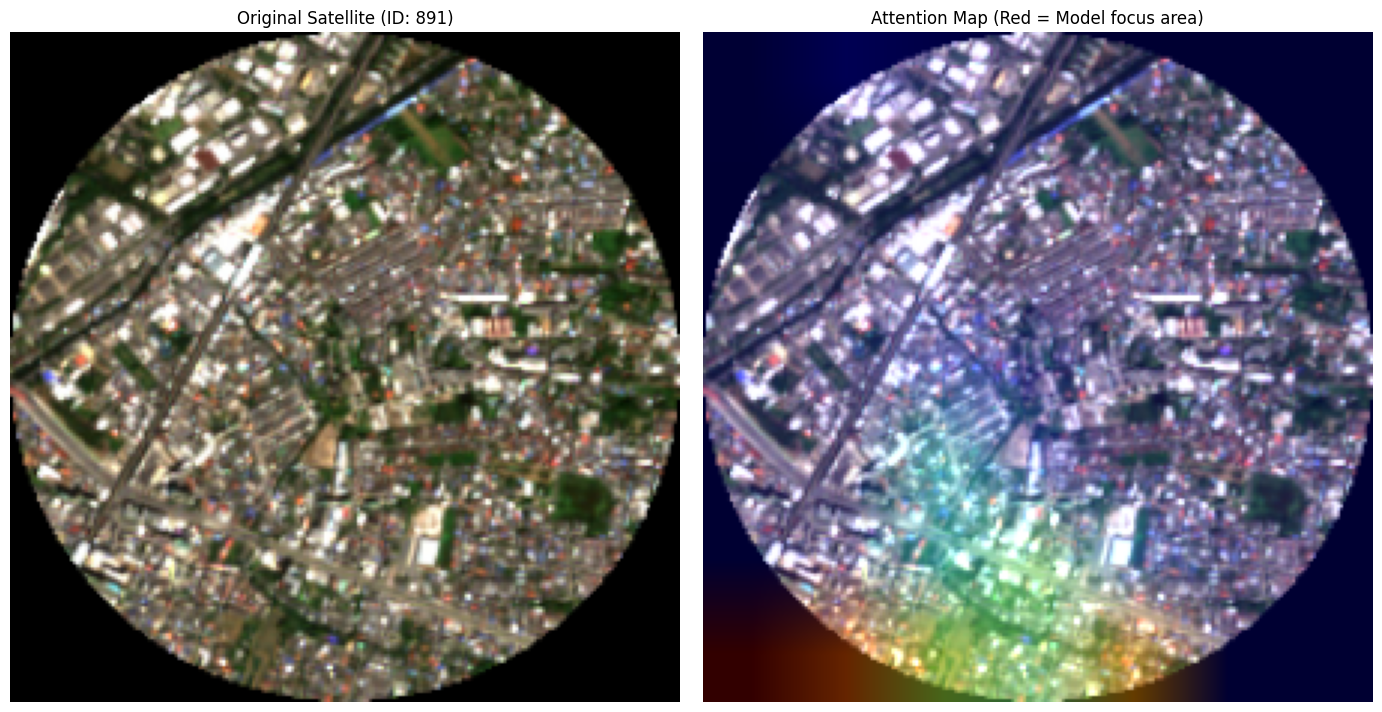

✅ Grad-CAM Generated Successfully!


In [34]:
import cv2
import matplotlib.cm as cm
import matplotlib.pyplot as plt

# RANDOM IMAGE ATTENTION MAP (Grad-CAM)

def get_gradcam_heatmap(img_array, model, last_conv_layer_name, pred_index=None):
    grad_model = Model(
        inputs=[model.inputs],
        outputs=[model.get_layer(last_conv_layer_name).output, model.output]
    )

    with tf.GradientTape() as tape:
        last_conv_layer_output, preds = grad_model(img_array)
        if pred_index is None:
            class_channel = tf.reduce_mean(preds, axis=-1)
        else:
            class_channel = preds[:, pred_index]

    grads = tape.gradient(class_channel, last_conv_layer_output)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    last_conv_layer_output = last_conv_layer_output[0]
    heatmap = last_conv_layer_output @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    heatmap = tf.maximum(heatmap, 0) / tf.math.reduce_max(heatmap)
    return heatmap.numpy()

def display_random_gradcam(X_imgs, df_info, model, img_dir, last_conv_layer="top_activation"):
    total_images = len(X_imgs)
    random_idx = np.random.randint(0, total_images)
    
    sample_img_input = np.expand_dims(X_imgs[random_idx], axis=0)
    sample_img_id = df_info.iloc[random_idx]['id']
    sample_img_path = os.path.join(img_dir, f"{sample_img_id}.tif")
    
    print(f"🎲 Randomly Selected Image Index: {random_idx}")
    print(f"🔍 Analyzing Image ID: {sample_img_id}")

    try:
        heatmap = get_gradcam_heatmap(sample_img_input, model, last_conv_layer)
        
        img = cv2.imread(sample_img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = cv2.resize(img, (224, 224))

        heatmap_resized = np.uint8(255 * heatmap)
        jet = cm.get_cmap("jet")
        jet_colors = jet(np.arange(256))[:, :3]
        jet_heatmap = jet_colors[heatmap_resized]
        jet_heatmap = cv2.resize(jet_heatmap, (img.shape[1], img.shape[0]))
        jet_heatmap = np.uint8(jet_heatmap * 255)

        alpha = 0.4
        superimposed_img = jet_heatmap * alpha + img
        superimposed_img = np.clip(superimposed_img, 0, 255).astype('uint8')

        plt.figure(figsize=(14, 7))
        plt.subplot(1, 2, 1)
        plt.title(f"Original Satellite (ID: {sample_img_id})")
        plt.imshow(img)
        plt.axis("off")

        plt.subplot(1, 2, 2)
        plt.title("Attention Map (Red = Model focus area)")
        plt.imshow(superimposed_img)
        plt.axis("off")
        
        plt.tight_layout()
        plt.show()
        
        print("✅ Grad-CAM Generated Successfully!")
        
    except Exception as e:
        print(f"❌ Error: {e}")

display_random_gradcam(X_imgs, df_final_base, poi_model, IMAGE_DIR)

In [26]:
import joblib

save_path = 'saved_models'
if not os.path.exists(save_path):
    os.makedirs(save_path)

# --- 1. เซฟโมเดลสกัดฟีเจอร์จากภาพ (Keras .h5 หรือ .keras) ---
extractor.save(os.path.join(save_path, 'image_feature_extractor.h5'))
print("✅ Saved: Image Feature Extractor")

# --- 2. เซฟ PCA (เพื่อลดมิติภาพให้เหลือ 50 เท่าเดิมตอนใช้งานจริง) ---
joblib.dump(pca, os.path.join(save_path, 'pca_processor.pkl'))
print("✅ Saved: PCA Processor")

# --- 3. เซฟโมเดลที่ดีที่สุดจาก Leaderboard (XGBoost/LightGBM + Preprocessor)
best_model = grid.best_estimator_ 
joblib.dump(best_model, os.path.join(save_path, 'final_condo_price_model.pkl'))
print("✅ Saved: Final Prediction Model (The Winner)")

# --- 4. เซฟรายชื่อคอลัมน์ (Feature Names) ---

feature_columns = X_train.columns.tolist()
joblib.dump(feature_columns, os.path.join(save_path, 'model_columns.pkl'))
print("✅ Saved: Model Feature Columns (Order-preserved)")

print(f"\n🚀 ทั้งหมดถูกบันทึกไว้ที่โฟลเดอร์: {save_path}")
print(f"📦 ไฟล์ที่ต้องใช้ใน Flask: \n 1. image_feature_extractor.h5 \n 2. pca_processor.pkl \n 3. final_condo_price_model.pkl \n 4. model_columns.pkl")

print(f"\n🚀 ทั้งหมดถูกบันทึกไว้ที่โฟลเดอร์: {save_path}")

✅ Saved: Image Feature Extractor
✅ Saved: PCA Processor
✅ Saved: Final Prediction Model (The Winner)
✅ Saved: Model Feature Columns (Order-preserved)

🚀 ทั้งหมดถูกบันทึกไว้ที่โฟลเดอร์: saved_models
📦 ไฟล์ที่ต้องใช้ใน Flask: 
 1. image_feature_extractor.h5 
 2. pca_processor.pkl 
 3. final_condo_price_model.pkl 
 4. model_columns.pkl

🚀 ทั้งหมดถูกบันทึกไว้ที่โฟลเดอร์: saved_models


In [27]:
# รันดูรายชื่อเขต
ohe_categories = grid.best_estimator_.named_steps['preprocessor'].named_transformers_['cat'].categories_[0]
print(f"ระบบรองรับทั้งหมด {len(ohe_categories)} เขต ดังนี้:")
print(ohe_categories)

ระบบรองรับทั้งหมด 46 เขต ดังนี้:
['Bang Bon' 'Bang Kapi' 'Bang Khae' 'Bang Khen' 'Bang Kho Laem'
 'Bang Khun Thian' 'Bang Na' 'Bang Phlat' 'Bang Rak' 'Bang Sue'
 'Bangkok Noi' 'Bangkok Yai' 'Bueng Kum' 'Chatuchak' 'Chom Thong'
 'Din Daeng' 'Don Mueang' 'Dusit' 'Huai Khwang' 'Khan Na Yao' 'Khlong San'
 'Khlong Toei' 'Lak Si' 'Lat Krabang' 'Lat Phrao' 'Min Buri' 'Pathum Wan'
 'Phasi Charoen' 'Phaya Thai' 'Phra Khanong' 'Phra Nakhon'
 'Pom Prap Sattru Phai' 'Prawet' 'Rat Burana' 'Ratchathewi' 'Sai Mai'
 'Samphanthawong' 'Saphan Sung' 'Sathon' 'Suan Luang' 'Taling Chan'
 'Thon Buri' 'Thung Khru' 'Wang Thonglang' 'Watthana' 'Yan Nawa']


Top 5 Most Influential Factors:
                      feature  importance
2          num__internal_area       14565
5             num__year_built        1166
104         num__smart_img_40         987
83          num__smart_img_19         688
70           num__smart_img_6         645
3                 num__floors         634
74          num__smart_img_10         623
80          num__smart_img_16         621
18   num__city_train_distance         620
0               num__bedrooms         617


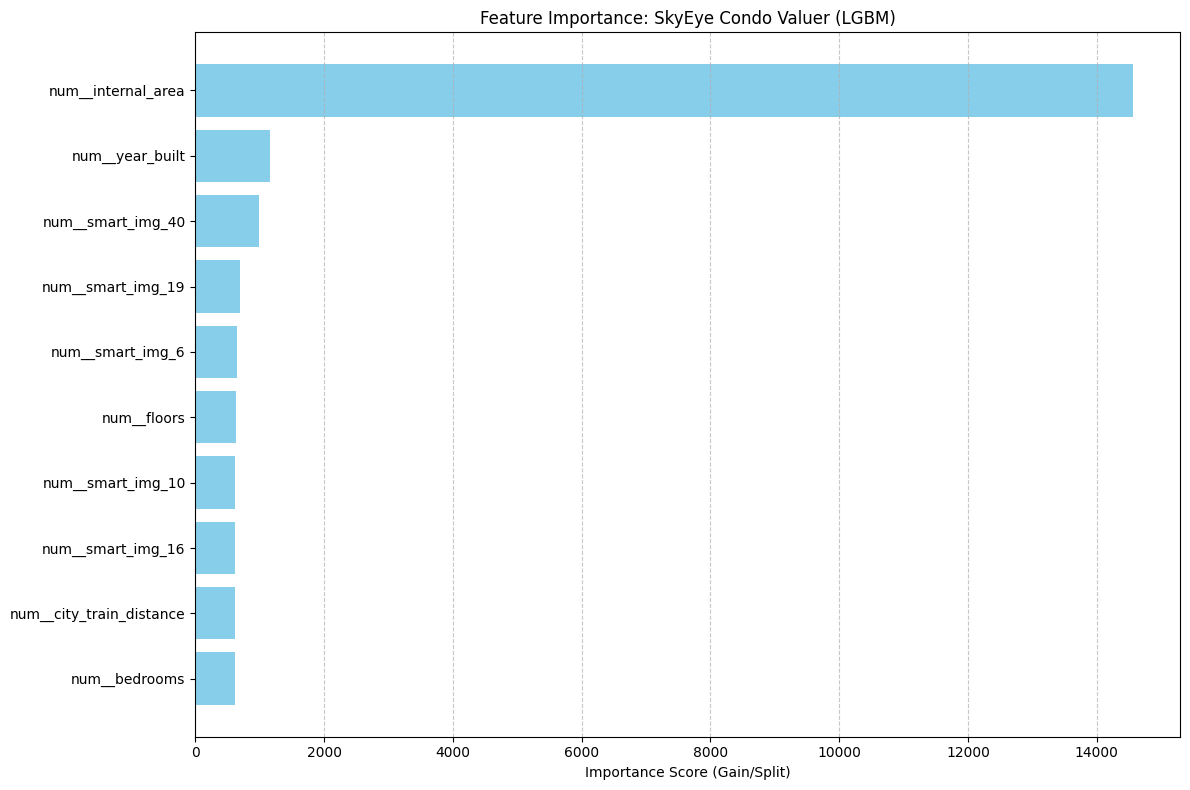

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import joblib

# 1. โหลด Pipeline
model_pipeline = joblib.load(r'C:\Users\Asus\Desktop\project\final\model\training\Multimodal&FineTuning\saved_models\final_condo_price_model.pkl')

# 2. ดึงรายชื่อฟีเจอร์ที่ผ่านการ Transform แล้ว (สำคัญมากสำหรับ OneHotEncoder)
# ดึงชื่อจากขั้นตอน 'preprocessor'
feature_names = model_pipeline.named_steps['preprocessor'].get_feature_names_out()

# 3. ดึงค่า Feature Importance จากขั้นตอน 'regressor'
importances = model_pipeline.named_steps['regressor'].feature_importances_

# 4. สร้าง DataFrame เพื่อสรุปผล
importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': importances
}).sort_values(by='importance', ascending=False)

# 5. แสดงผล 15 อันดับแรก
print("Top 5 Most Influential Factors:")
print(importance_df.head(10))

# 6. พลอตกราฟ
plt.figure(figsize=(12, 8))
plt.barh(importance_df['feature'].head(10), importance_df['importance'].head(10), color='skyblue')
plt.gca().invert_yaxis()
plt.xlabel('Importance Score (Gain/Split)')
plt.title('Feature Importance: SkyEye Condo Valuer (LGBM)')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()
# กราฟคลาดเคลื่อนกับตัวที่อยู่ในรายงานเพราะผมรัน training ใหม่ เพราะพลาดไปกดรันตอนจะก็อฟภาพ ภาพเลยหายและต้องรันงานใหม่ถึงจะได้ภาพออกมาครับ

In [30]:
import numpy as np
import tensorflow as tf
import cv2
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import os

def compare_feature_attention(pca_indices, X_imgs, df_info, extractor_model, pca_processor, img_dir):
    """
    เปรียบเทียบ High Attention ของหลายๆ PCA Features โดยใช้รูปภาพใบเดียวกัน
    """
    try:
        # 1. สุ่มเลือกรูปภาพจาก Dataset มา 1 รูป (เพื่อใช้เป็นฐานเดียวกัน)
        random_idx = np.random.randint(0, len(X_imgs))
        sample_img_input = np.expand_dims(X_imgs[random_idx], axis=0)
        sample_img_id = df_info.iloc[random_idx]['id']
        
        # เตรียมภาพต้นฉบับสำหรับแสดงผล
        img_path = os.path.join(img_dir, f"{sample_img_id}.tif")
        img_orig = cv2.imread(img_path)
        img_orig = cv2.cvtColor(img_orig, cv2.COLOR_BGR2RGB)
        img_orig = cv2.resize(img_orig, (224, 224))

        # เตรียม Figure สำหรับวาดภาพ (1 แถว, จำนวนคอลัมน์ = ต้นฉบับ + จำนวนฟีเจอร์)
        num_features = len(pca_indices)
        plt.figure(figsize=(5 * (num_features + 1), 5))

        # Plot ภาพต้นฉบับช่องแรก
        plt.subplot(1, num_features + 1, 1)
        plt.title(f"Original Satellite\nID: {sample_img_id}")
        plt.imshow(img_orig)
        plt.axis("off")

        # 2. วนลูปสร้าง Heatmap สำหรับแต่ละ PCA Index
        for i, pca_idx in enumerate(pca_indices):
            # Inverse PCA เพื่อหานิวรอนต้นตอ
            weights = pca_processor.components_[pca_idx]
            original_neuron_idx = np.argmax(np.abs(weights))

            # สร้าง Grad-CAM
            grad_model = tf.keras.models.Model(
                [extractor_model.inputs], 
                [extractor_model.get_layer('top_activation').output, extractor_model.output]
            )

            with tf.GradientTape() as tape:
                conv_outputs, feature_vectors = grad_model(sample_img_input)
                target_neuron_value = feature_vectors[:, original_neuron_idx]

            grads = tape.gradient(target_neuron_value, conv_outputs)
            pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
            heatmap = conv_outputs[0] @ pooled_grads[..., tf.newaxis]
            heatmap = tf.squeeze(heatmap)
            heatmap = tf.maximum(heatmap, 0) / (tf.math.reduce_max(heatmap) + 1e-10)
            heatmap = heatmap.numpy()

            # ตกแต่งภาพ Heatmap
            heatmap_resized = np.uint8(255 * heatmap)
            jet = cm.get_cmap("jet")
            jet_colors = jet(np.arange(256))[:, :3]
            jet_heatmap = jet_colors[heatmap_resized]
            jet_heatmap = cv2.resize(jet_heatmap, (img_orig.shape[1], img_orig.shape[0]))
            jet_heatmap = np.uint8(jet_heatmap * 255)

            superimposed_img = cv2.addWeighted(img_orig, 0.6, jet_heatmap, 0.4, 0)

            # Plot ลงในช่องถัดไป
            plt.subplot(1, num_features + 1, i + 2)
            plt.title(f"Attention: smart_img_{pca_idx}")
            plt.imshow(superimposed_img)
            plt.axis("off")

        plt.tight_layout()
        plt.show()
        print(f"✅ แสดงผลเปรียบเทียบฟีเจอร์ {pca_indices} สำเร็จโดยใช้ภาพเดียวกัน")

    except Exception as e:
        print(f"❌ เกิดข้อผิดพลาด: {e}")

# --- วิธีเรียกใช้งานพร้อมกัน ---
# ส่งค่าเป็น List [13, 0] เพื่อดูเปรียบเทียบกัน
compare_feature_attention([13, 0], X_imgs, df_final_base, IMG_EXTRACTOR, PCA_PROCESSOR, IMAGE_DIR)

NameError: name 'IMG_EXTRACTOR' is not defined